/tmp/ipykernel_1131/1972398018.py:107: RuntimeWarning: invalid value encountered in subtract
  t_prime = (4.0 * u_n1 - u_n2) / 3.0


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


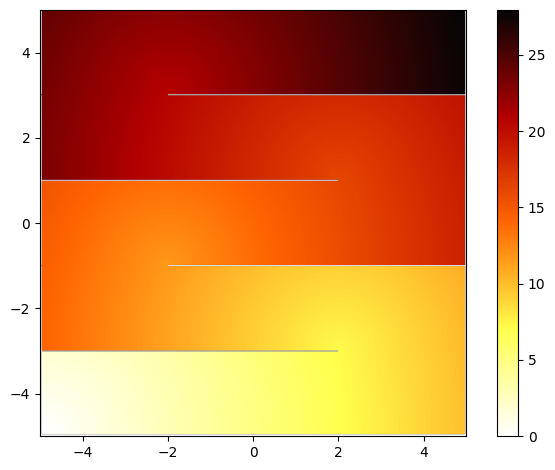

In [ ]:
# ==============================================================================
# --------------------------FIM CON GODUNOV 2 ----------------------------------
# ==============================================================================

"""
Il seguente codice utilizza il metodo del FIM classico (v2) con l'aggiornamento
di Godunov del 2° ordine (quello a 4 punti )per generare la soluzione T_final su
cui poi è stato integrato il raggio tramite il metodo di Rounge-Kutta del 4°ordine.
Il gradiente lo si è discretizzato con le differenze finite e interpolato
linearmente. In particolare si è usata la derivata centrata nei punti lontani
dai muri, con la backward per i punti a sx di un muro e forward per i punti alla
dx di un muro
"""

#------------------  LIBRERIE --------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from typing import Text
from matplotlib import animation, rc
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive
from scipy.ndimage import distance_transform_edt

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------

nx = 500
ny = 500
nRows = 500
nCols = 500
sidex = 5
sidey = 5
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)
eps = 1e-6

ix0 = 5
iy0 = 5

#------------------  CAMPO DI VELOCITA' (LABIRINTO) ----------------------------

F = np.ones(X.shape)
F_oncart = RegularGridInterpolator((X[0, :], Y[:, 0]), F.T, method='linear', bounds_error=False, fill_value=None)

F = 1 * np.ones(X.shape)

# pareti del bordo
F[:, 1]   = np.inf   # parete sinistra
F[:, 498] = np.inf   # parete destra
F[1, :]   = np.inf   # parete sopra
F[498, :] = np.inf   # parete sotto

# primo muro orizzontale (riga 100, con apertura a sinistra)
F[99, :]       = np.inf
F[99, 349:498] = 1   # apertura: colonne 350-498 in MATLAB → 349:498 in Python

# secondo muro orizzontale (riga 200, con apertura a destra)
F[199, :]      = np.inf
F[199, 1:150]  = 1   # apertura: colonne 2-150 in MATLAB → 1:150 in Python

# terzo muro orizzontale (riga 300, con apertura a sinistra)
F[299, :]       = np.inf
F[299, 349:498] = 1

# quarto muro orizzontale (riga 400, con apertura a destra)
F[399, :]      = np.inf
F[399, 1:150]  = 1

wall_mask = np.isinf(F)

# ==============================================================================
# CALCOLO FIM
# ==============================================================================

#------------------  SORGENTE --------------------------------------------------

T = np.full(X.shape, np.inf)
T[iy0, ix0] = 0

active = np.zeros(T.shape, dtype=bool)

for dr, dc in [(0,-1),(0,1),(-1,0),(1,0)]:
    nr, nc = iy0 + dr, ix0 + dc
    if 0 <= nr < nRows and 0 <= nc < nCols:
        active[nr, nc] = True

T_old = np.full(T.shape, np.inf)
continua = True
h = dx

#------------------ GODUNOV 2 --------------------------------------------------

def _dir_contribution(u0, u_n1, u_n2, valid1, valid2, alpha, alpha_prime):

    use = valid1 & (u0 > u_n1)

    second_ok = use & valid2 & (u_n2 < u_n1)
    first_ok  = use & ~second_ok

    t_prime = (4.0 * u_n1 - u_n2) / 3.0
    beta2   = -2.0 * alpha_prime * t_prime
    gamma2  = alpha_prime * (t_prime ** 2)

    beta1  = -(2.0 * u_n1 * alpha)
    gamma1 = (u_n1 ** 2) * alpha

    a_c = np.where(second_ok, alpha_prime, np.where(first_ok, alpha, 0.0))
    b_c = np.where(second_ok, beta2,       np.where(first_ok, beta1, 0.0))
    c_c = np.where(second_ok, gamma2,      np.where(first_ok, gamma1, 0.0))

    return a_c, b_c, c_c


def Godunov_update_2nd(T, F, row, col):

    u0 = T[row, col]

    def neighbor(rr, cc, axis_len_r=nRows, axis_len_c=nCols):
        rr_c = np.clip(rr, 0, axis_len_r - 1)
        cc_c = np.clip(cc, 0, axis_len_c - 1)
        return rr_c, cc_c

    # --- direzione riga meno (i-1, i-2) ---
    r_m1, r_m2 = row - 1, row - 2
    rc1, _ = neighbor(r_m1, col)
    rc2, _ = neighbor(r_m2, col)
    valid_m1 = (r_m1 >= 0) & ~wall_mask[rc1, col]
    valid_m2 = valid_m1 & (r_m2 >= 0) & ~wall_mask[rc2, col]
    u_rm1, u_rm2 = T[rc1, col], T[rc2, col]

    # --- direzione riga più (i+1, i+2) ---
    r_p1, r_p2 = row + 1, row + 2
    rc1, _ = neighbor(r_p1, col)
    rc2, _ = neighbor(r_p2, col)
    valid_p1 = (r_p1 < nRows) & ~wall_mask[rc1, col]
    valid_p2 = valid_p1 & (r_p2 < nRows) & ~wall_mask[rc2, col]
    u_rp1, u_rp2 = T[rc1, col], T[rc2, col]

    # --- direzione colonna meno (j-1, j-2) ---
    c_m1, c_m2 = col - 1, col - 2
    _, cc1 = neighbor(row, c_m1)
    _, cc2 = neighbor(row, c_m2)
    valid_cm1 = (c_m1 >= 0) & ~wall_mask[row, cc1]
    valid_cm2 = valid_cm1 & (c_m2 >= 0) & ~wall_mask[row, cc2]
    u_cm1, u_cm2 = T[row, cc1], T[row, cc2]

    # --- direzione colonna più (j+1, j+2) ---
    c_p1, c_p2 = col + 1, col + 2
    _, cc1 = neighbor(row, c_p1)
    _, cc2 = neighbor(row, c_p2)
    valid_cp1 = (c_p1 < nCols) & ~wall_mask[row, cc1]
    valid_cp2 = valid_cp1 & (c_p2 < nCols) & ~wall_mask[row, cc2]
    u_cp1, u_cp2 = T[row, cc1], T[row, cc2]

    alpha       = 1.0 / (h ** 2)
    alpha_prime = 9.0 / (4.0 * h ** 2)

    a = np.zeros_like(u0)
    b = np.zeros_like(u0)
    c = -(F[row, col] ** 2) * np.ones_like(u0)

    for u_n1, u_n2, v1, v2 in [
        (u_rm1, u_rm2, valid_m1, valid_m2),
        (u_rp1, u_rp2, valid_p1, valid_p2),
        (u_cm1, u_cm2, valid_cm1, valid_cm2),
        (u_cp1, u_cp2, valid_cp1, valid_cp2),
    ]:
        a_c, b_c, c_c = _dir_contribution(u0, u_n1, u_n2, v1, v2, alpha, alpha_prime)
        a += a_c
        b += b_c
        c += c_c

    disc = b ** 2 - 4.0 * a * c

    safe_a = np.where(a == 0, 1.0, a)          # evita divisione per zero
    u_quad = (-b + np.sqrt(np.maximum(disc, 0.0))) / (2.0 * safe_a)
    u_lin  = -b / (2.0 * safe_a)               # ramo "not isreal" del MATLAB

    u_new = np.where(disc >= 0, u_quad, u_lin)
    u_new = np.where(a == 0, u0, u_new)        # nessun vicino valido: resta invariato

    return np.minimum(u0, u_new)

#------------------  AGGIORNAMENTO FIM -----------------------------------------

def FIM(T, F, active):

    while np.any(active):

        row, col = np.where(active)
        p = T[row, col]
        q = Godunov_update_2nd(T, F, row, col)

        T[row, col] = q             # ← aggiorna T PRIMA del controllo convergenza

        converged_cond = np.abs(p - q) < eps
        conv_row, conv_col = row[converged_cond], col[converged_cond]

        active[conv_row, conv_col] = False

        for r, c in [(0, -1), (0, 1), (-1, 0), (1, 0)]:
            nb_row = conv_row + r
            nb_col = conv_col + c

            valid = (nb_row >= 0) & (nb_row < nRows) & (nb_col >= 0) & (nb_col < nCols)
            nb_row, nb_col = nb_row[valid], nb_col[valid]

            not_active = ~active[nb_row, nb_col]

            wall = np.isinf(F[nb_row, nb_col])

            nb_row = nb_row[~wall]
            nb_col = nb_col[~wall]

            if nb_row.size == 0:
                continue

            p2 = T[nb_row, nb_col]
            q2 = Godunov_update_2nd(T, F, nb_row, nb_col)

            improve = q2 < p2
            nb_row, nb_col, q2 = nb_row[improve], nb_col[improve], q2[improve]

            T[nb_row, nb_col] = q2
            active[nb_row, nb_col] = True

    return T


T_final = FIM(T, F, active)

#------------------  SALVATAGGIO IN DRIVE --------------------------------------

"""
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/Colab Notebooks/Risultati/'


np.savez(save_path + 'T_fim_cpu_ordine2.npz', T_FIMcpu_ordine2 = T_final)
"""
#------------------  STAMPA DEI RISULTATI --------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
im.set_cmap(cmap2)

plt.tight_layout()
plt.show()

